# Data Preparation

## Loading Data

In [1]:
# load libraries
from pathlib import Path
import json
import pandas as pd
import numpy as np
from PIL import Image
from pycocotools.coco import COCO
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [2]:
DATA_DIR = Path('/Users/minkhant/Downloads/Grad-CAM_CarDD/data')
SPLIT_FOLDERS = {
    "train" : "train2017",
    "val" : "val2017",
    "test" : "test2017",
}

In [3]:
annotations = {}
image_records = []

for split, folder in SPLIT_FOLDERS.items():
    # Load the COCO annotations for this split.
    annotation_file = DATA_DIR / f"annotations/instances_{folder}.json"
    with open(annotation_file, "r") as f:
        annotations[split] = json.load(f)
    
    for image in annotations[split]["images"]:
        image_record = {
            "split" : split,
            "image_id" : image["id"],
            "file_name" : image["file_name"],
            "width" : image["width"],
            "height" : image["height"],
            }
        image_records.append(image_record)

image_df = pd.DataFrame(image_records)
    
print(image_df.head())
print(image_df.groupby("split").size())

   split  image_id   file_name  width  height
0  train         1  000001.jpg   1000     750
1  train         2  000002.jpg   1000     667
2  train         3  000003.jpg   1000     667
3  train         4  000004.jpg   1000     667
4  train         5  000005.jpg   1000     667
split
test      374
train    2816
val       810
dtype: int64


## Validate the images and annotations

In [4]:
issues = []
def report(split, item_type, item_id, problem):
    issues.append({
        "split" : split,
        "type" : item_type,
        "id" : item_id,
        "problem" : problem,
    })

In [5]:
for split, folder in SPLIT_FOLDERS.items():
    dataset = annotations[split]
    
    coco = COCO()
    coco.dataset = dataset
    coco.createIndex()
    
    images_by_id = {image["id"] : image for image in dataset["images"]}
    category_ids = {cat["id"] for cat in dataset["categories"]}
    
    # Check for duplicate IDs in images, annotations and categories before creating the index.
    for key in ["images", "annotations", "categories"]:
        ids = [item["id"] for item in dataset[key]]
        if len(ids) != len(set(ids)):
            report(split, key, None, "Duplicate IDs")
            
    # Validate original image files
    for image in dataset["images"]:
        path = DATA_DIR / folder / image["file_name"]
        
        try:
            with Image.open(path) as img:
                img.load() # Decode the image to check for corruption
                
                expected_size = (image["width"], image["height"])
                if img.size != expected_size:
                    report(
                        split, "image", image["id"],
                        f"Image size mismatch: file={img.size}, "
                        f"annotation={expected_size}"
                    )
        except Exception as error:
            report(split, "image", image["id"], str(error))
            
    # Validate annotations
    for ann in dataset["annotations"]:
        ann_id = ann["id"]
        image = images_by_id.get(ann["image_id"])

        if image is None:
            report(split, "annotation", ann_id, "Unknown image ID")
            continue

        if ann["category_id"] not in category_ids:
            report(split, "annotation", ann_id, "Unknown category ID")

        width, height = image["width"], image["height"]

        try:
            bbox = np.asarray(ann["bbox"], dtype=float)

            if bbox.shape != (4,) or not np.isfinite(bbox).all():
                raise ValueError("Box must contain four finite numbers")

            # COCO bounding boxes use [x, y, width, height].
            x, y, box_width, box_height = bbox

            if box_width <= 0 or box_height <= 0:
                raise ValueError("Box width or height is not positive")

            left = max(0, int(np.floor(x)))
            top = max(0, int(np.floor(y)))
            right = min(width, int(np.ceil(x + box_width)))
            bottom = min(height, int(np.ceil(y + box_height)))

            if left >= right or top >= bottom:
                raise ValueError("Box does not overlap the image")

            if (
                x < 0 or y < 0
                or x + box_width > width
                or y + box_height > height
            ):
                report(
                    split, "annotation", ann_id,
                    "Box extends outside image; clip during extraction"
                )

        except Exception as error:
            report(split, "annotation", ann_id, f"Invalid box: {error}")
            continue

        try:
            mask = coco.annToMask(ann)

            if mask.shape != (height, width):
                report(split, "annotation", ann_id, "Mask size mismatch")
            elif not mask.any():
                report(split, "annotation", ann_id, "Empty damage mask")
            elif not mask[top:bottom, left:right].any():
                report(
                    split, "annotation", ann_id,
                    "No damage pixels inside the crop"
                )

        except Exception as error:
            report(
                split, "annotation", ann_id,
                f"Cannot decode mask: {error}"
            )
            
    print(
        f"{split}: checked {len(dataset['images'])} images "
        f"and {len(dataset['annotations'])} annotations"
    )

creating index...
index created!
train: checked 2816 images and 6211 annotations
creating index...
index created!
val: checked 810 images and 1744 annotations
creating index...
index created!
test: checked 374 images and 785 annotations


In [6]:
issues_df = pd.DataFrame(
    issues, columns=["split", "type", "id", "problem"]
)

print(f"\nTotal reported issues: {len(issues_df)}")
display(issues_df.head(30))


Total reported issues: 0


,split,type,id,problem


## Extract and inspect one damage crop

In [7]:
CROP_PADDING = 0.25


def padded_crop_box(bbox, image_width, image_height, padding):
    """Expand a COCO box by a fixed fraction per side and clip to the image."""
    x, y, width, height = map(float, bbox)
    if not all(math.isfinite(v) for v in (x, y, width, height, padding)):
        raise ValueError("Bounding box and padding must be finite.")
    if width <= 0 or height <= 0 or padding < 0:
        raise ValueError("Box dimensions must be positive and padding nonnegative.")
    if image_width <= 0 or image_height <= 0:
        raise ValueError("Image dimensions must be positive.")
    if x >= image_width or y >= image_height or x + width <= 0 or y + height <= 0:
        raise ValueError("The original box does not overlap the image.")

    left = max(0, math.floor(x - padding * width))
    top = max(0, math.floor(y - padding * height))
    right = min(image_width, math.ceil(x + width + padding * width))
    bottom = min(image_height, math.ceil(y + height + padding * height))
    return left, top, right, bottom

train_data = annotations["train"]
ann = train_data["annotations"][10]

In [8]:
images_by_id = {
    image["id"] : image
    for image in train_data["images"]
}
category_names = {
    category["id"] :category["name"]
    for category in train_data["categories"]
}

image_info = images_by_id[ann["image_id"]]
label = category_names[ann["category_id"]]

image_path = (
    DATA_DIR / SPLIT_FOLDERS["train"] / image_info["file_name"]
)

with Image.open(image_path) as img:
    original = img.convert("RGB")

crop_box = padded_crop_box(
    ann["bbox"],
    original.width,
    original.height,
    CROP_PADDING,
)
left, top, right, bottom = crop_box
damage_crop = original.crop(crop_box)

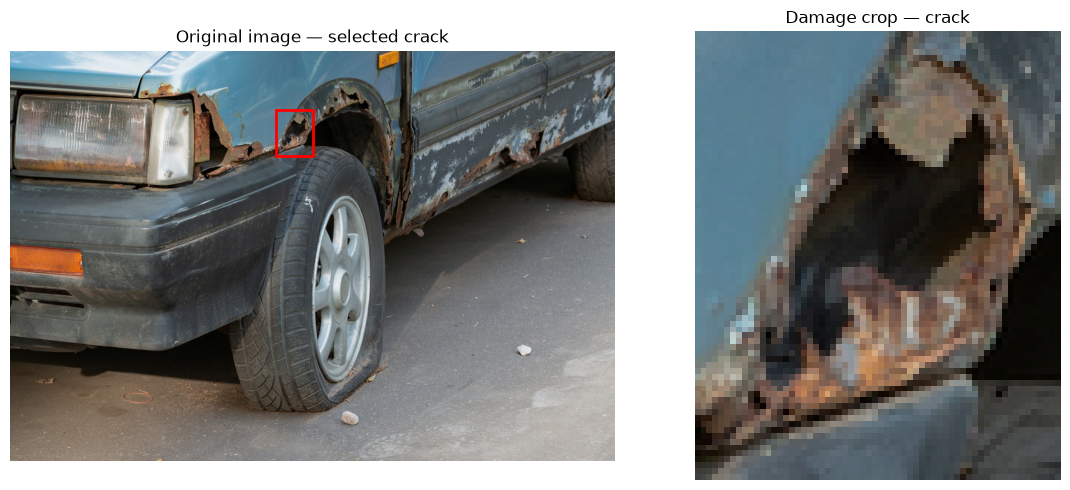

{'split': 'train', 'image_id': 8, 'annotation_id': 11, 'category_id': 3, 'label': 'crack', 'crop_box': (439, 98, 501, 174), 'padding_fraction_per_side': 0.25}
Crop size (width, height): (62, 76)


In [9]:
# Keep metadata for the matching mask and later dataset creation.
crop_metadata = {
    "split": "train",
    "image_id": image_info["id"],
    "annotation_id": ann["id"],
    "category_id": ann["category_id"],
    "label": label,
    "crop_box": crop_box,
    "padding_fraction_per_side": CROP_PADDING,
}

# Display the source image and extracted crop.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(original)
axes[0].add_patch(
    Rectangle(
        (left, top),
        right - left,
        bottom - top,
        linewidth=2,
        edgecolor="red",
        facecolor="none",
    )
)
axes[0].set_title(f"Original image — selected {label}")
axes[0].axis("off")

axes[1].imshow(damage_crop)
axes[1].set_title(f"Damage crop — {label}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print(crop_metadata)
print("Crop size (width, height):", damage_crop.size)

creating index...
index created!


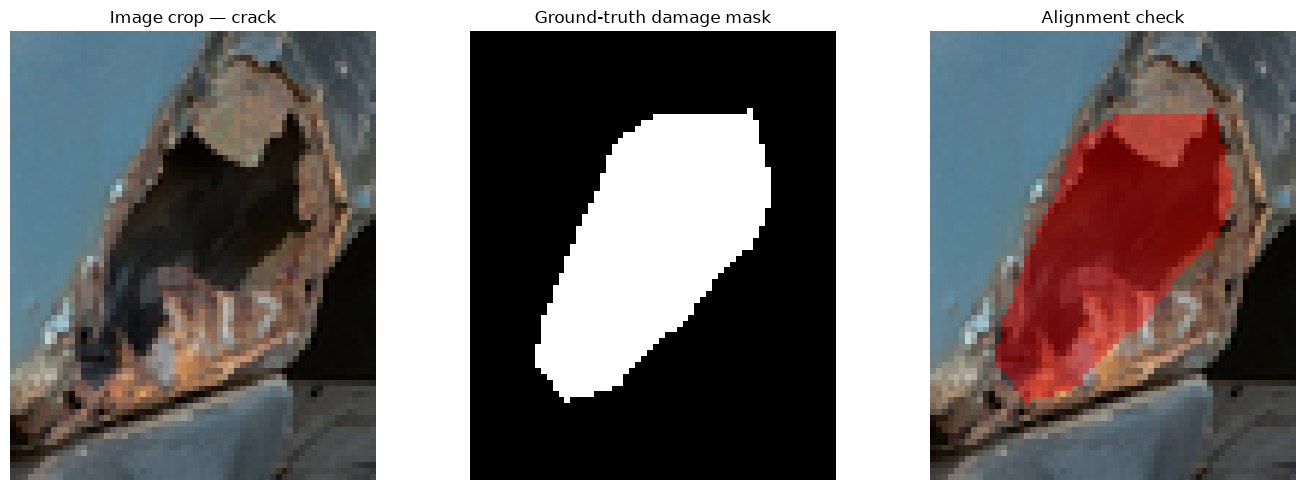

Annotation ID: 11
Image crop size (width, height): (62, 76)
Mask shape (height, width): (76, 62)
Mask values: [0 1]
Annotated damage covers 24.9% of the crop.


In [10]:
# Explicitly use training annotations.
coco_train = COCO()
coco_train.dataset = annotations["train"]
coco_train.createIndex()

# Decode the selected annotation into a full-image binary mask.
full_mask = coco_train.annToMask(ann)

assert full_mask.shape == (original.height, original.width), (
    "The mask dimensions do not match the original image."
)

# Apply exactly the same coordinates used for the image crop.
left, top, right, bottom = crop_box
damage_mask = (
    full_mask[top:bottom, left:right] > 0
).astype(np.uint8)

# Check dimensions and ensure the crop contains annotated damage.
assert damage_mask.shape == (
    damage_crop.height, damage_crop.width
), "The crop and mask dimensions do not match."

assert damage_mask.any(), "The cropped mask contains no damage pixels."

# Create a transparent red overlay for the annotated pixels.
overlay = np.zeros((*damage_mask.shape, 4), dtype=np.float32)
overlay[..., 0] = 1.0                    # Red channel
overlay[..., 3] = damage_mask * 0.4       # Opacity only on damage

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].imshow(damage_crop)
axes[0].set_title(f"Image crop — {label}")

axes[1].imshow(
    damage_mask,
    cmap="gray",
    vmin=0,
    vmax=1,
    interpolation="nearest",
)
axes[1].set_title("Ground-truth damage mask")

axes[2].imshow(damage_crop)
axes[2].imshow(overlay, interpolation="nearest")
axes[2].set_title("Alignment check")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

print("Annotation ID:", ann["id"])
print("Image crop size (width, height):", damage_crop.size)
print("Mask shape (height, width):", damage_mask.shape)
print("Mask values:", np.unique(damage_mask))
print(f"Annotated damage covers {damage_mask.mean():.1%} of the crop.")

In [11]:
# Define the model's class order explicitly.
CLASS_NAMES = [
    "dent",
    "scratch",
    "crack",
    "glass shatter",
    "lamp broken",
    "tire flat",
]

class_to_idx = {
    name: index
    for index, name in enumerate(CLASS_NAMES)
}

# Confirm that every split contains the same category names.
for split, dataset in annotations.items():
    names = {cat["name"] for cat in dataset["categories"]}
    assert names == set(CLASS_NAMES), (
        f"Unexpected categories in {split}: {names}"
    )

display(pd.DataFrame(
    class_to_idx.items(),
    columns=["category", "class_index"],
))

,category,class_index
0,dent,0
1,scratch,1
2,crack,2
3,glass shatter,3
4,lamp broken,4
5,tire flat,5


In [12]:
sample_records = []

for split, dataset in annotations.items():
    images_by_id = {
        image["id"]: image
        for image in dataset["images"]
    }
    category_names = {
        category["id"]: category["name"]
        for category in dataset["categories"]
    }

    for annotation in dataset["annotations"]:
        image = images_by_id[annotation["image_id"]]
        category = category_names[annotation["category_id"]]

        left, top, right, bottom = padded_crop_box(
            annotation["bbox"], image["width"], image["height"], CROP_PADDING
        )

        # Include the split to avoid assuming IDs are globally unique.
        sample_id = (
            f"{split}_img{image['id']}_ann{annotation['id']}"
        )

        sample_records.append({
            "sample_id": sample_id,
            "split": split,
            "image_id": image["id"],
            "annotation_id": annotation["id"],
            "source_path": str(
                DATA_DIR
                / SPLIT_FOLDERS[split]
                / image["file_name"]
            ),
            "category_id": annotation["category_id"],
            "category": category,
            "class_index": class_to_idx[category],
            "padding_fraction_per_side": CROP_PADDING,
            "left": left,
            "top": top,
            "right": right,
            "bottom": bottom,
            "crop_width": right - left,
            "crop_height": bottom - top,
        })

samples_df = pd.DataFrame(sample_records)

assert samples_df["sample_id"].is_unique, "Duplicate sample IDs found."

display(samples_df.head())

display(
    pd.crosstab(samples_df["category"], samples_df["split"])
    .reindex(index=CLASS_NAMES, columns=["train", "val", "test"])
)

,sample_id,split,image_id,annotation_id,source_path,category_id,category,class_index,padding_fraction_per_side,left,top,right,bottom,crop_width,crop_height
0,train_img1_ann1,train,1,1,/Users/minkhant/Downloads/Grad-CAM_CarDD/data/...,2,scratch,1,0.25,116,7,421,205,305,198
1,train_img1_ann2,train,1,2,/Users/minkhant/Downloads/Grad-CAM_CarDD/data/...,6,tire flat,5,0.25,0,0,1000,750,1000,750
2,train_img2_ann3,train,2,3,/Users/minkhant/Downloads/Grad-CAM_CarDD/data/...,6,tire flat,5,0.25,377,154,974,667,597,513
3,train_img3_ann4,train,3,4,/Users/minkhant/Downloads/Grad-CAM_CarDD/data/...,6,tire flat,5,0.25,192,0,1000,652,808,652
4,train_img4_ann5,train,4,5,/Users/minkhant/Downloads/Grad-CAM_CarDD/data/...,6,tire flat,5,0.25,0,0,1000,667,1000,667


split,train,val,test
category,,,
dent,1806,501,236
scratch,2560,728,307
crack,651,177,70
glass shatter,475,135,71
lamp broken,494,141,69
tire flat,225,62,32


In [13]:
df = samples_df.copy()

In [14]:
display(df.head())
df.info()

print("Total samples:", len(df))
print("Unique sample IDs:", df["sample_id"].nunique())
print("Duplicate sample IDs:", df["sample_id"].duplicated().sum())

display(
    df.isna()
    .sum()
    .rename("missing_values")
    .to_frame()
)

,sample_id,split,image_id,annotation_id,source_path,category_id,category,class_index,padding_fraction_per_side,left,top,right,bottom,crop_width,crop_height
0,train_img1_ann1,train,1,1,/Users/minkhant/Downloads/Grad-CAM_CarDD/data/...,2,scratch,1,0.25,116,7,421,205,305,198
1,train_img1_ann2,train,1,2,/Users/minkhant/Downloads/Grad-CAM_CarDD/data/...,6,tire flat,5,0.25,0,0,1000,750,1000,750
2,train_img2_ann3,train,2,3,/Users/minkhant/Downloads/Grad-CAM_CarDD/data/...,6,tire flat,5,0.25,377,154,974,667,597,513
3,train_img3_ann4,train,3,4,/Users/minkhant/Downloads/Grad-CAM_CarDD/data/...,6,tire flat,5,0.25,192,0,1000,652,808,652
4,train_img4_ann5,train,4,5,/Users/minkhant/Downloads/Grad-CAM_CarDD/data/...,6,tire flat,5,0.25,0,0,1000,667,1000,667


<class 'pandas.DataFrame'>
RangeIndex: 8740 entries, 0 to 8739
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   sample_id                  8740 non-null   str    
 1   split                      8740 non-null   str    
 2   image_id                   8740 non-null   int64  
 3   annotation_id              8740 non-null   int64  
 4   source_path                8740 non-null   str    
 5   category_id                8740 non-null   int64  
 6   category                   8740 non-null   str    
 7   class_index                8740 non-null   int64  
 8   padding_fraction_per_side  8740 non-null   float64
 9   left                       8740 non-null   int64  
 10  top                        8740 non-null   int64  
 11  right                      8740 non-null   int64  
 12  bottom                     8740 non-null   int64  
 13  crop_width                 8740 non-null   int64  
 14  cro

,missing_values
sample_id,0
split,0
image_id,0
annotation_id,0
source_path,0
category_id,0
category,0
class_index,0
padding_fraction_per_side,0
left,0


In [15]:
split_summary = (
    df.groupby("split")
    .agg(
        crops=("sample_id", "size"),
        source_images=("source_path", "nunique"),
    )
    .reindex(["train", "val", "test"])
)

split_summary["crops_per_image"] = (
    split_summary["crops"] / split_summary["source_images"]
)

display(split_summary.round(2))

,crops,source_images,crops_per_image
split,,,
train,6211,2816,2.21
val,1744,810,2.15
test,785,374,2.10


split,train,val,test
category,,,
dent,1806,501,236
scratch,2560,728,307
crack,651,177,70
glass shatter,475,135,71
lamp broken,494,141,69
tire flat,225,62,32


split,train,val,test
category,,,
dent,29.08,28.73,30.06
scratch,41.22,41.74,39.11
crack,10.48,10.15,8.92
glass shatter,7.65,7.74,9.04
lamp broken,7.95,8.08,8.79
tire flat,3.62,3.56,4.08


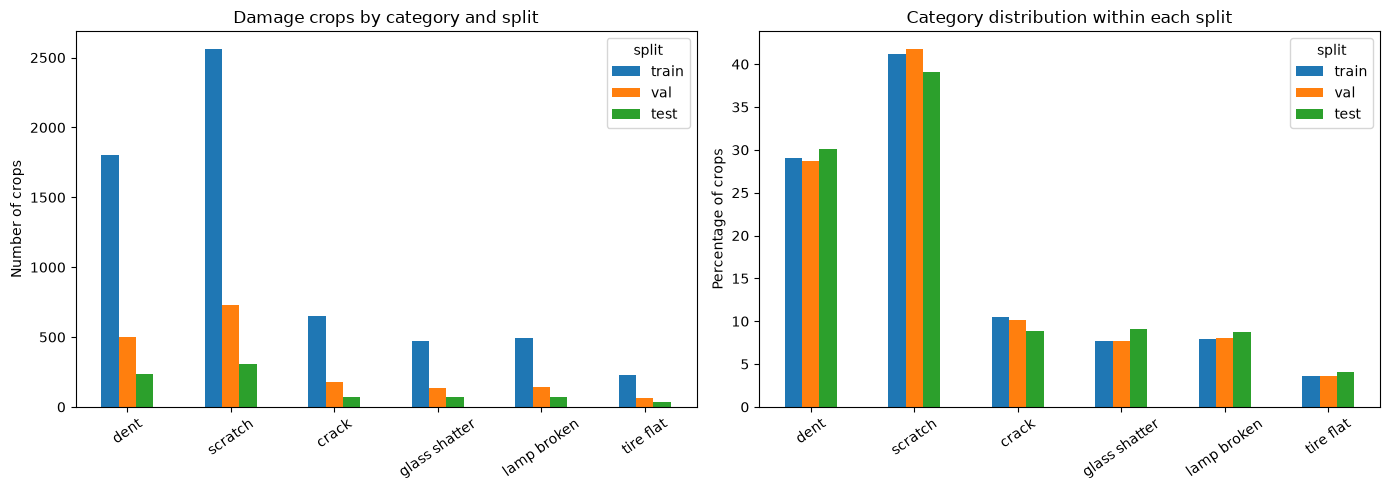

In [16]:
class_counts = pd.crosstab(
    df["category"],
    df["split"],
).reindex(
    index=CLASS_NAMES,
    columns=["train", "val", "test"],
    fill_value=0,
)

class_percentages = (
    class_counts.div(class_counts.sum(axis=0), axis=1) * 100
)

display(class_counts)
display(class_percentages.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts.plot.bar(ax=axes[0])
axes[0].set_title("Damage crops by category and split")
axes[0].set_ylabel("Number of crops")

class_percentages.plot.bar(ax=axes[1])
axes[1].set_title("Category distribution within each split")
axes[1].set_ylabel("Percentage of crops")

for ax in axes:
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

,crop_width,crop_height,aspect_ratio,crop_area
count,6211.00,6211.00,6211.00,6211.00
mean,457.69,338.98,1.68,197375.08
std,293.07,214.92,1.45,206435.49
min,13.00,12.00,0.07,300.00
5%,74.00,58.00,0.43,6061.50
25%,208.00,156.00,0.89,34054.50
50%,404.00,298.00,1.35,111398.00
75%,667.00,510.00,1.95,306032.00
95%,1000.00,668.00,4.10,665000.00
max,1000.00,1000.00,24.57,1000000.00


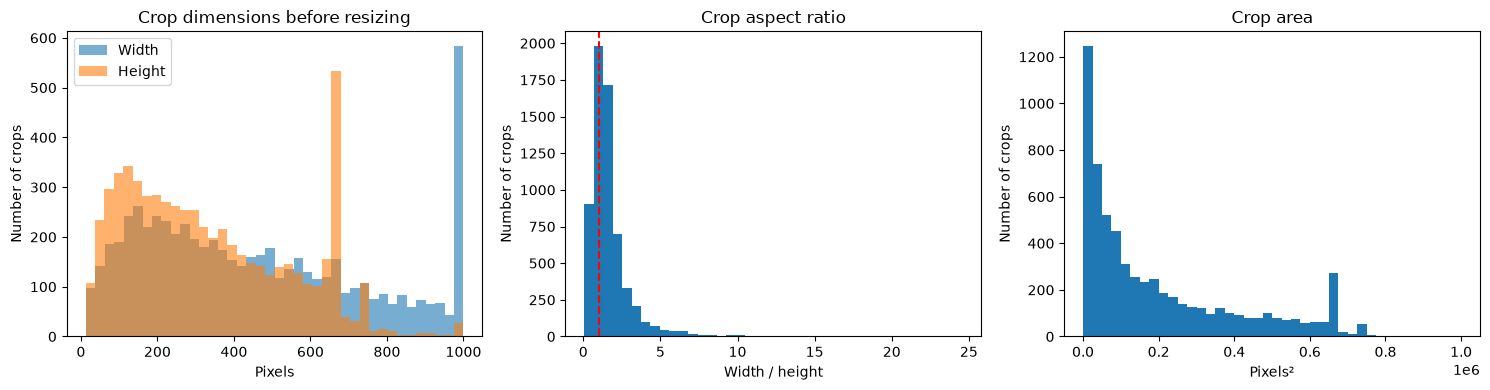

In [17]:
train_eda = df[
    df["split"] == "train"
].copy()

train_eda["aspect_ratio"] = (
    train_eda["crop_width"] / train_eda["crop_height"]
)
train_eda["crop_area"] = (
    train_eda["crop_width"] * train_da["crop_height"]
) if False else (
    train_eda["crop_width"] * train_eda["crop_height"]
)

display(
    train_eda[
        ["crop_width", "crop_height", "aspect_ratio", "crop_area"]
    ].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(2)
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(train_eda["crop_width"], bins=40, alpha=0.6, label="Width")
axes[0].hist(train_eda["crop_height"], bins=40, alpha=0.6, label="Height")
axes[0].set_title("Crop dimensions before resizing")
axes[0].set_xlabel("Pixels")
axes[0].legend()

axes[1].hist(train_eda["aspect_ratio"], bins=40)
axes[1].axvline(1, color="red", linestyle="--")
axes[1].set_title("Crop aspect ratio")
axes[1].set_xlabel("Width / height")

axes[2].hist(train_eda["crop_area"], bins=40)
axes[2].set_title("Crop area")
axes[2].set_xlabel("Pixels²")

for ax in axes:
    ax.set_ylabel("Number of crops")

plt.tight_layout()
plt.show()

,damage_instances,damage_categories
count,2816.00,2816.00
mean,2.21,1.55
std,1.55,0.80
min,1.00,1.00
25%,1.00,1.00
50%,2.00,1.00
75%,3.00,2.00
max,13.00,5.00


Training images with multiple damage categories: 1084


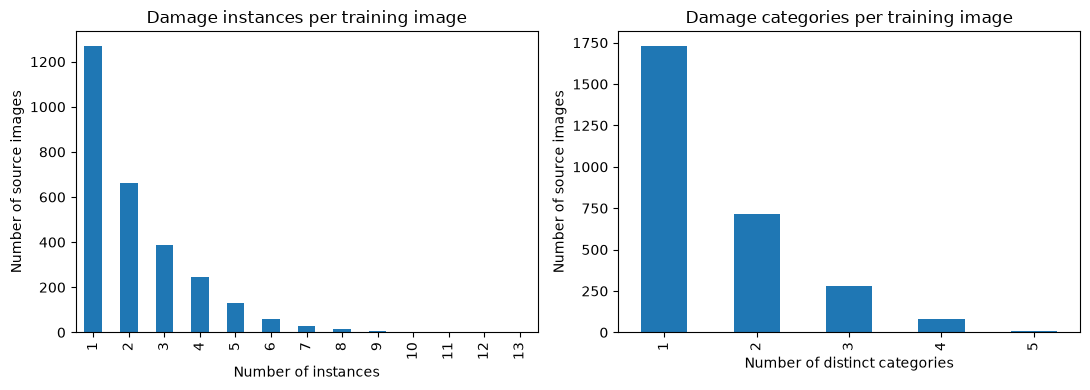

In [18]:
per_image = (
    train_eda.groupby("source_path")
    .agg(
        damage_instances=("annotation_id", "size"),
        damage_categories=("category", "nunique"),
    )
)

display(per_image.describe().round(2))

print(
    "Training images with multiple damage categories:",
    int((per_image["damage_categories"] > 1).sum()),
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

per_image["damage_instances"].value_counts().sort_index().plot.bar(
    ax=axes[0]
)
axes[0].set_title("Damage instances per training image")
axes[0].set_xlabel("Number of instances")

per_image["damage_categories"].value_counts().sort_index().plot.bar(
    ax=axes[1]
)
axes[1].set_title("Damage categories per training image")
axes[1].set_xlabel("Number of distinct categories")

for ax in axes:
    ax.set_ylabel("Number of source images")

plt.tight_layout()
plt.show()

In [19]:
invalid_geometry = df[
    (df["left"] < 0)
    | (df["top"] < 0)
    | (df["right"] <= df["left"])
    | (df["bottom"] <= df["top"])
    | (
        df["crop_width"]
        != df["right"] - df["left"]
    )
    | (
        df["crop_height"]
        != df["bottom"] - df["top"]
    )
]

print("Rows with invalid crop geometry:", len(invalid_geometry))
display(invalid_geometry.head())

if "padding_fraction_per_side" in df.columns:
    display(pd.crosstab(
        df["padding_fraction_per_side"],
        df["split"],
    ))
else:
    print("Padding metadata is missing. Check whether this is the old manifest.")

Rows with invalid crop geometry: 0


,sample_id,split,image_id,annotation_id,source_path,category_id,category,class_index,padding_fraction_per_side,left,top,right,bottom,crop_width,crop_height


split,test,train,val
padding_fraction_per_side,,,
0.25,785,6211,1744


In [20]:
# Separate outputs for each padding experiment.
padding_tag = f"padding_{CROP_PADDING * 100:g}pct_per_side"
OUTPUT_DIR = DATA_DIR.parent / "processed" / padding_tag
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

samples_df.to_csv(OUTPUT_DIR / "sample_manifest.csv", index=False)

with (OUTPUT_DIR / "class_to_idx.json").open("w") as f:
    json.dump(class_to_idx, f, indent=2)

print("Saved metadata to:", OUTPUT_DIR)
with (OUTPUT_DIR / "crop_config.json").open("w") as f:
    json.dump({
        "crop_rule": "bbox_fraction_per_side_round_outward_clip_to_image",
        "padding_fraction_per_side": CROP_PADDING,
        "mask_rule": "selected_annotation_sliced_with_same_crop_box",
    }, f, indent=2)

Saved metadata to: /Users/minkhant/Downloads/Grad-CAM_CarDD/processed/padding_25pct_per_side
